# Variance Reduction Demonstration : Linear Regression

We are setting out to reproduce the [pymc3 linear regression tutorial](https://www.pymc.io/projects/examples/en/2022.01.0/samplers/MLDA_variance_reduction_linear_regression.html) for variance reduction.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az

from scipy.integrate import solve_ivp

import ray
ray.init(_system_config={"local_fs_capacity_threshold": 0.99})

import tinyDA as tda

2026-09-30 15:28:59,379	INFO worker.py:2024 -- Started a local Ray instance.


In [2]:
np.random.seed(123)

In [3]:
class LinearModel:
    def __init__(self, x):
        self.x = x
    def __call__(self, parameters):
        out = parameters[0] + parameters[1] * self.x
        return out, out.mean()          # (model output, QoI)

In [4]:
x = np.linspace(0, 1, 100)

sigma = 0.2 # note: pymc3 tutorial uses sigma**2 as the std
sigma_true = sigma**2

y = 1 + 2*x + np.random.normal(0, 0.2**2, 100)   # pymc3 uses sigma**2 as the std

models = [LinearModel(x[::3]), LinearModel(x[::2]), LinearModel(x)]
datasets = [y[::3], y[::2], y]

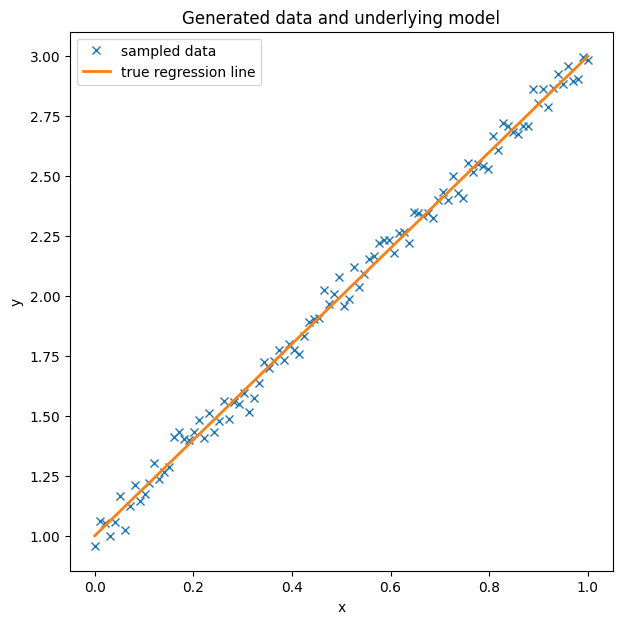

In [6]:
# Plot the data
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, xlabel="x", ylabel="y", title="Generated data and underlying model")
ax.plot(x, y, "x", label="sampled data")
ax.plot(x, 1 + 2*x , label="true regression line", lw=2.0)
plt.legend(loc=0)
plt.show()

In [5]:
# setting up the inverse problem
prior = stats.multivariate_normal(np.zeros(2), 400*np.eye(2))   # pymc3 Normal(0, sigma=20) priors

posteriors = [tda.Posterior(prior, tda.GaussianLogLike(d, 0.2**2*np.eye(d.size)), m)
              for m, d in zip(models, datasets)]

In [6]:
# random walk Metropolis
rwmh_cov = np.eye(2)
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# preconditioned Crank-Nicolson
#pcn_scaling = 0.1
#pcn_adaptive = True
#my_proposal = tda.CrankNicolson(scaling=pcn_scaling, adaptive=pcn_adaptive)

# adaptive Metropolis
#am_cov = np.eye(2)*0.01
#am_t0 = 1000
#am_sd = None
#am_epsilon = 1e-6
#am_adaptive = True
#my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

In [7]:
burnin = 1000       # TO DO: solve ray issue (for now we just force sequential chains)
n_draws = 3000 + burnin

nsub = 10
nchains = 2

chain = tda.sample(posteriors, my_proposal, iterations=n_draws, 
                   n_chains=nchains, subchain_length=nsub, randomize_subchain_length=True, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/4000 [00:00<?, ?it/s]/Users/louisekluge/mlda-variance-reduction/.pixi/envs/default/lib/python3.11/site-packages/tinyDA/proposal.py:258: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 1.00:   0%|          | 0/4000 [00:00<?, ?it/s]/Users/louisekluge/mlda-variance-reduction/.pixi/envs/default/lib/python3.11/site-packages/tinyDA/proposal.py:1658: RuntimeWarning: overflow encountered in exp
  return np.exp(
Running chain, α = 0.59: 100%|██████████| 4000/4000 [01:59<00:00, 33.36it/s]


Sampling chain 2/2


Running chain, α = 0.68: 100%|██████████| 4000/4000 [02:01<00:00, 32.89it/s]


In [8]:
mlinf = tda.get_multilevel_inference_data(chain, attribute='qoi', burnin=burnin)

np.savez('qoi_linear.npz',
         **{k: np.asarray(v) for k, v in mlinf['chains'].items()},
         **{f'prom_{k}': np.asarray(v) for k, v in mlinf['promoted'].items()})

In [9]:
d = np.load('qoi_linear.npz')  

Q0  = np.hstack((d['level0_chain0'], d['level0_chain1']))   # (n_samples, 2)
Q2  = np.hstack((d['level2_chain0'], d['level2_chain1']))
Y10 = np.hstack((d['level1_chain0'], d['level1_chain1'])) \
    - np.hstack((d['prom_level0_chain0'], d['prom_level0_chain1']))
Y21 = np.hstack((d['level2_chain0'], d['level2_chain1'])) \
    - np.hstack((d['prom_level1_chain0'], d['prom_level1_chain1']))

# sanity: paired arrays must align elementwise
assert len(d['level1_chain0']) == len(d['prom_level0_chain0'])
assert len(d['level2_chain0']) == len(d['prom_level1_chain0'])

# level growth ratios, measured not assumed (~nsub and ~nsub²)
r1 = len(d['level1_chain0']) / len(Q2)
r0 = len(Q0) / len(Q2)

def se(x):
    """Standard error of the mean of x, shape (n_draws, n_chains)."""
    x = np.asarray(x, dtype=np.float64).T          # -> (chain, draw)
    return np.sqrt(x.var() / az.ess(x))

N    = len(Q2)
step = 100
idx  = np.arange(200, N + 1, step)      # start at 200: ESS on tiny prefixes is junk

STD_SE = np.array([se(Q2[:i]) for i in idx])
VR_SE  = np.array([np.sqrt(se(Q0[:int(i * r0)])**2
                         + se(Y10[:int(i * r1)])**2
                         + se(Y21[:i])**2) for i in idx])

plt.plot(2*idx, STD_SE, label="Standard estimator")
plt.plot(2*idx, VR_SE,  label="Variance reduction estimator")
plt.xlabel("Fine-level samples"); plt.ylabel("Standard error"); plt.legend()
plt.show()

<Figure size 640x480 with 1 Axes>

/Users/louisekluge/mlda-variance-reduction/.pixi/envs/default/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>]],
      dtype=object)

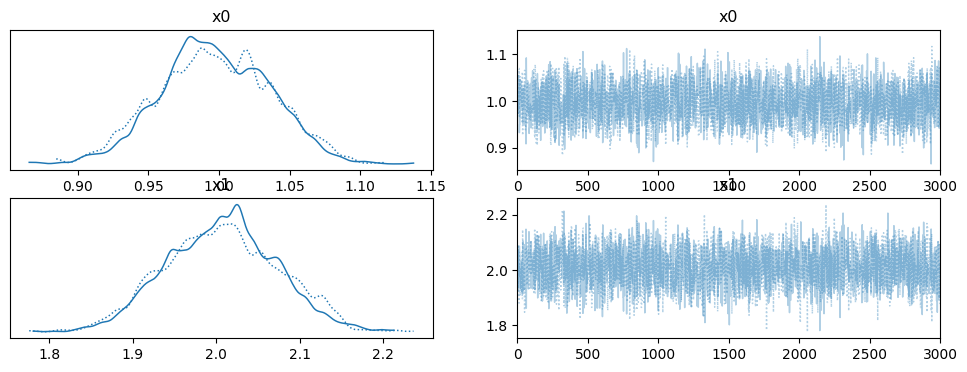

In [15]:
# show trace plot
idata = tda.to_inference_data(chain, level=2, burnin=1000)
az.plot_trace(idata)

In [10]:
for name, arr in [('Q2', Q2), ('Q0', Q0), ('Y10', Y10), ('Y21', Y21)]:
    a = np.asarray(arr, float).T
    print(f'{name}: var={a.var():.3e} ess={az.ess(a):.0f} var/ess={a.var()/az.ess(a):.3e}')

Q2: var=3.694e-04 ess=2707 var/ess=1.365e-07
Q0: var=9.736e-04 ess=65037 var/ess=1.497e-08
Y10: var=5.715e-04 ess=23330 var/ess=2.450e-08
Y21: var=4.760e-04 ess=4519 var/ess=1.053e-07


## Variance Reduction: State-Paired vs. Proposal-Paired

In [11]:
def state_pair(fine, promoted):
    """Hold the previous promoted value whenever the fine chain didn't move."""
    fine = np.ravel(np.asarray(fine, float))
    prom = np.ravel(np.asarray(promoted, float))
    moved = np.r_[True, np.diff(fine) != 0]
    idx_hold = np.maximum.accumulate(np.where(moved, np.arange(len(prom)), 0))
    return fine - prom[idx_hold]

Y10_s = np.column_stack([state_pair(d[f'level1_chain{c}'], d[f'prom_level0_chain{c}'])
                         for c in range(nchains)])
Y21_s = np.column_stack([state_pair(d[f'level2_chain{c}'], d[f'prom_level1_chain{c}'])
                         for c in range(nchains)])

In [12]:
VR_SE_state = np.array([np.sqrt(se(Q0[:int(i*r0)])**2
                              + se(Y10_s[:int(i*r1)])**2
                              + se(Y21_s[:i])**2) for i in idx])

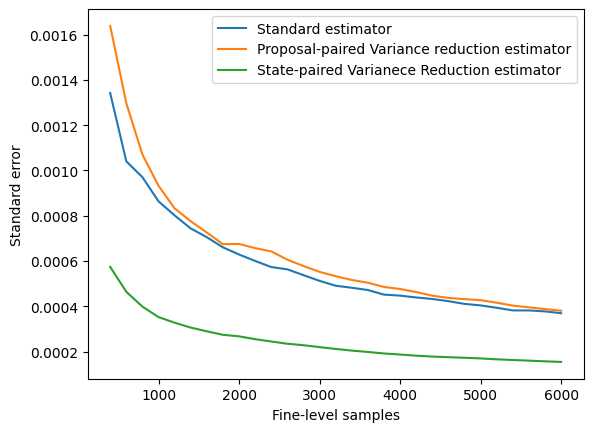

In [14]:
plt.plot(2*idx, STD_SE, label="Standard estimator")
plt.plot(2*idx, VR_SE,  label="Proposal-paired Variance reduction estimator")
plt.plot(2*idx, VR_SE_state, label='State-paired Varianece Reduction estimator')
plt.xlabel("Fine-level samples"); plt.ylabel("Standard error"); plt.legend()
plt.show()                              # reference

In [15]:
print('proposal-paired:', Q0.mean() + Y10.mean() + Y21.mean(),
      'SE', np.sqrt(se(Q0)**2 + se(Y10)**2 + se(Y21)**2))
print('state-paired:  ', Q0.mean() + Y10_s.mean() + Y21_s.mean(),
      'SE', np.sqrt(se(Q0)**2 + se(Y10_s)**2 + se(Y21_s)**2))
print('ref:   ', Q2.mean(), 'SE', se(Q2))

proposal-paired: 2.0012358831182118 SE 0.0003805114461128908
state-paired:   1.997079691572136 SE 0.0001544092883400956
ref:    2.0014265197508427 SE 0.0003694208408406185


In [16]:
for name, arr in [('Y10_s', Y10_s), ('Y21_s', Y21_s)]:
    a = np.asarray(arr, float).T
    print(f'{name}: var={a.var():.3e} ess={az.ess(a):.0f} var/ess={a.var()/az.ess(a):.3e}')

Y10_s: var=9.960e-05 ess=11363 var/ess=8.766e-09
Y21_s: var=2.600e-07 ess=2448 var/ess=1.062e-10
